In [ ]:
!pip install -q torch torchvision scikit-learn matplotlib pandas


In [1]:
import random, time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets
from sklearn.model_selection import train_test_split
import pickle

In [17]:
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PRETRAIN_EPOCHS = 10      # можно увеличить: 50+ для лучших результатов
CLF_EPOCHS = 5

BATCH_PRETRAIN = 256 if torch.cuda.is_available() else 128
BATCH_CLF = 128
LR_PRETRAIN = 1e-3
LR_CLF = 1e-3
TEMPERATURE = 0.5

FRACTIONS = [100, 50, 10]  # % labeled to use


Device: cuda


In [18]:
root = "./data"
trainset = datasets.FashionMNIST(root, train=True, download=True)
testset = datasets.FashionMNIST(root, train=False, download=True)
x_train = trainset.data.numpy()  # uint8 Nx28x28
y_train = trainset.targets.numpy()
x_test = testset.data.numpy()
y_test = testset.targets.numpy()

In [19]:
def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
def augment_pil(img):
    w,h = img.size
    scale = random.uniform(0.8, 1.0)
    nw, nh = int(w*scale), int(h*scale)
    left = random.randint(0, w-nw)
    top = random.randint(0, h-nh)
    img2 = img.crop((left, top, left+nw, top+nh)).resize((28,28))
    if random.random() < 0.5:
        img2 = ImageOps.mirror(img2)
    img2 = img2.rotate(random.uniform(-15, 15))
    img2 = ImageEnhance.Brightness(img2).enhance(random.uniform(0.9,1.1))
    return img2

def pil_to_tensor(img):
    arr = np.array(img).astype('float32')/255.0
    arr = (arr - 0.5) / 0.5
    return torch.from_numpy(arr).unsqueeze(0)

class SimCLRArrayDataset(Dataset):
    def __init__(self, images):
        self.images = images
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = to_pil(self.images[idx])
        a = augment_pil(img); b = augment_pil(img)
        return pil_to_tensor(a), pil_to_tensor(b)

class LabeledArrayDataset(Dataset):
    def __init__(self, images, labels, indices):
        self.images = images; self.labels = labels; self.indices = indices
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        i = self.indices[idx]
        img = to_pil(self.images[i])
        return pil_to_tensor(img), int(self.labels[i])



In [20]:
all_idx = list(range(len(x_train)))
train_pool_idx, val_idx = train_test_split(all_idx, test_size=0.1, stratify=y_train, random_state=SEED)
val_dataset = LabeledArrayDataset(x_train, y_train, val_idx)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=2)

In [21]:
class SmallEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1))
        )
        self.out_dim = out_dim
        self.fc = nn.Linear(128, out_dim)
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, in_dim), nn.ReLU(), nn.Linear(in_dim, proj_dim))
    def forward(self, x): return self.net(x)

def nt_xent_loss(z1, z2, temperature=0.5):
    z = torch.cat([z1, z2], dim=0)
    z = F.normalize(z, dim=1)
    sim = torch.matmul(z, z.T) / temperature
    N = z1.size(0)
    mask = (~torch.eye(2*N, dtype=bool, device=z.device)).float()
    exp_sim = torch.exp(sim) * mask
    denom = exp_sim.sum(dim=1, keepdim=True)
    positives = torch.cat([torch.diag(sim, N), torch.diag(sim, -N)]).unsqueeze(1)
    loss = -torch.log(torch.exp(positives) / denom)
    return loss.mean()

In [22]:
pretrain_dataset = SimCLRArrayDataset(x_train)
pretrain_loader = DataLoader(pretrain_dataset, batch_size=BATCH_PRETRAIN, shuffle=True, num_workers=2)

encoder = SmallEncoder(out_dim=128).to(device)
proj = ProjectionHead(128, proj_dim=64).to(device)
opt = optim.Adam(list(encoder.parameters()) + list(proj.parameters()), lr=LR_PRETRAIN)

pretrain_losses = []
for epoch in range(PRETRAIN_EPOCHS):
    encoder.train(); proj.train()
    running = 0.0; it = 0
    t0 = time.time()
    for a,b in pretrain_loader:
        a=a.to(device); b=b.to(device)
        z1 = proj(encoder(a)); z2 = proj(encoder(b))
        loss = nt_xent_loss(z1, z2, temperature=TEMPERATURE)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item(); it += 1
    pretrain_losses.append(running/it)
    print(f"Pretrain epoch {epoch+1}/{PRETRAIN_EPOCHS}, loss={pretrain_losses[-1]:.4f}, time={(time.time()-t0):.1f}s")

/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')


Pretrain epoch 1/10, loss=4.8636, time=14.9s


/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')


Pretrain epoch 2/10, loss=4.5878, time=14.3s


/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')


...

Pretrain epoch 8/10, loss=4.4484, time=14.1s


/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')


Pretrain epoch 9/10, loss=4.4413, time=14.3s


/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')


Pretrain epoch 10/10, loss=4.4337, time=14.3s


In [23]:
class Classifier(nn.Module):
    def __init__(self, encoder, num_classes=10, freeze_encoder=False):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(encoder.out_dim, num_classes)
        if freeze_encoder:
            for p in self.encoder.parameters(): p.requires_grad=False
    def forward(self, x):
        feats = self.encoder(x)
        return self.classifier(feats), feats

def train_eval_clf(model, train_loader, val_loader, epochs=30, lr=1e-3):
    model.to(device)
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss':[], 'val_loss':[], 'val_acc':[]}
    for epoch in range(epochs):
        model.train()
        run=0.0; cnt=0
        for xb,yb in train_loader:
            xb=xb.to(device); yb=yb.to(device)
            logits,_ = model(xb)
            loss = criterion(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            run += loss.item()*xb.size(0); cnt += xb.size(0)
        train_loss = run/cnt
        model.eval()
        run=0.0; cnt=0; corr=0
        with torch.no_grad():
            for xb,yb in val_loader:
                xb=xb.to(device); yb=yb.to(device)
                logits,_ = model(xb)
                loss = criterion(logits,yb)
                run += loss.item()*xb.size(0); cnt += xb.size(0)
                preds = logits.argmax(dim=1)
                corr += (preds==yb).sum().item()
        val_loss = run/cnt; val_acc = corr/cnt
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
        if (epoch+1)%5==0 or epoch in (0, epochs-1):
            print(f"  Epoch {epoch+1}/{epochs} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    return history, model

In [33]:
import traceback

results = []
plots_data = {}

for perc in FRACTIONS:
    print(f"\n === Fraction: {perc}% labeled ===")

    try:
        n_labeled = int(len(train_pool_idx) * perc / 100.0)
        pool_labels = np.array([y_train[i] for i in train_pool_idx])
        quotas = (np.bincount(pool_labels) / pool_labels.size * n_labeled).astype(int)
        while quotas.sum() < n_labeled:
            quotas[np.argmax(np.bincount(pool_labels))] += 1

        chosen = []
        for cls, q in enumerate(quotas):
            cls_idx = [train_pool_idx[i] for i in range(len(train_pool_idx)) if pool_labels[i] == cls]
            chosen += random.sample(cls_idx, min(q, len(cls_idx)))
        chosen = chosen[:n_labeled]

        train_dataset = LabeledArrayDataset(x_train, y_train, chosen)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_CLF, shuffle=True, num_workers=2)

        print(f"Training baseline model (from scratch) for {perc}% labeled...")
        enc_scratch = SmallEncoder(out_dim=128)
        clf_scratch = Classifier(enc_scratch, num_classes=10, freeze_encoder=False)
        h_scratch, m_scratch = train_eval_clf(clf_scratch, train_loader, val_loader,
                                              epochs=CLF_EPOCHS, lr=LR_CLF)
        print(f"Baseline training done ({perc}%).")


        print(f"Training classifier with pretrained encoder (frozen) for {perc}% labeled...")
        enc_pre = SmallEncoder(out_dim=128)
        enc_pre.load_state_dict(encoder.state_dict())
        clf_pre = Classifier(enc_pre, num_classes=10, freeze_encoder=True)
        h_pre, m_pre = train_eval_clf(clf_pre, train_loader, val_loader,
                                      epochs=CLF_EPOCHS, lr=LR_CLF)
        print(f" Pretrained training done ({perc}%).")


        print("Evaluating on test set...")
        test_loss_s, test_acc_s = eval_test(m_scratch, test_loader)
        test_loss_p, test_acc_p = eval_test(m_pre, test_loader)

        print(f" Appending results for {perc}%...")
        results.append({
            "percent": perc,
            "baseline_val_acc_max": max(h_scratch['val_acc']),
            "baseline_val_acc_final": h_scratch['val_acc'][-1],
            "baseline_test_acc": test_acc_s,
            "pretrained_val_acc_max": max(h_pre['val_acc']),
            "pretrained_val_acc_final": h_pre['val_acc'][-1],
            "pretrained_test_acc": test_acc_p,
            "baseline_train_loss_curve": h_scratch['train_loss'],
            "pretrained_train_loss_curve": h_pre['train_loss'],
            "baseline_val_loss_curve": h_scratch['val_loss'],
            "pretrained_val_loss_curve": h_pre['val_loss'],
            "baseline_val_acc_curve": h_scratch['val_acc'],
            "pretrained_val_acc_curve": h_pre['val_acc'],
        })
        plots_data[perc] = (h_scratch, h_pre, m_scratch, m_pre)

        df = pd.DataFrame(results)
        df.to_csv("ssl_results.csv", index=False)
        print(f"Saved results after {perc}% (total {len(results)} rows).")

    except Exception as e:
        print(f" Error during {perc}% training:")
        traceback.print_exc()

df = pd.DataFrame(results)
df.to_csv("ssl_results_final.csv", index=False)
print("\nAll experiments finished. Final results saved to ssl_results_final.csv")
print(df[["percent", "baseline_test_acc", "pretrained_test_acc"]])



 === Fraction: 100% labeled ===
Training baseline model (from scratch) for 100% labeled...


/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')


  Epoch 1/5 train_loss=0.9798 val_loss=0.6671 val_acc=0.7473


/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(a

  Epoch 5/5 train_loss=0.4369 val_loss=0.4081 val_acc=0.8553
Baseline training done (100%).
Training classifier with pretrained encoder (frozen) for 100% labeled...


...

  Epoch 1/5 train_loss=2.2131 val_loss=2.0958 val_acc=0.5370


/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(a

  Epoch 5/5 train_loss=1.5868 val_loss=1.5332 val_acc=0.6742
 Pretrained training done (10%).
Evaluating on test set...


/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')


 Appending results for 10%...
Saved results after 10% (total 3 rows).

All experiments finished. Final results saved to ssl_results_final.csv
   percent  baseline_test_acc  pretrained_test_acc
0      100             0.8417               0.7401
1       50             0.8154               0.7223
2       10             0.6915               0.6676


In [34]:
df

,percent,baseline_val_acc_max,baseline_val_acc_final,baseline_test_acc,pretrained_val_acc_max,pretrained_val_acc_final,pretrained_test_acc,baseline_train_loss_curve,pretrained_train_loss_curve,baseline_val_loss_curve,pretrained_val_loss_curve,baseline_val_acc_curve,pretrained_val_acc_curve
0,100,0.855333,0.855333,0.8417,0.750833,0.750833,0.7401,"[0.9797787545698661, 0.6478892387637386, 0.560...","[1.5955955269778217, 1.074228976867817, 0.9128...","[0.6671400017738343, 0.5932740181287129, 0.519...","[1.2117224168777465, 0.9620681948661804, 0.854...","[0.7473333333333333, 0.7688333333333334, 0.811...","[0.6995, 0.723, 0.7326666666666667, 0.74616666..."
1,50,0.824500,0.824500,0.8154,0.729167,0.729167,0.7223,"[1.203093123347671, 0.7371867169980649, 0.6510...","[1.8568297565954703, 1.3574056757114552, 1.136...","[0.8015622714360555, 0.6739065610567728, 0.587...","[1.5297314885457356, 1.2166877040863038, 1.057...","[0.7145, 0.7536666666666667, 0.782833333333333...","[0.6726666666666666, 0.6991666666666667, 0.713..."
2,10,0.692333,0.692333,0.6915,0.674167,0.674167,0.6676,"[1.9206091614122744, 1.2264475591094406, 0.995...","[2.213103366781164, 2.0060843314064876, 1.8374...","[1.424581031481425, 1.0760089848836263, 0.9471...","[2.0957787494659423, 1.9102039340337118, 1.758...","[0.45366666666666666, 0.6093333333333333, 0.65...","[0.537, 0.6388333333333334, 0.6525, 0.6645, 0...."


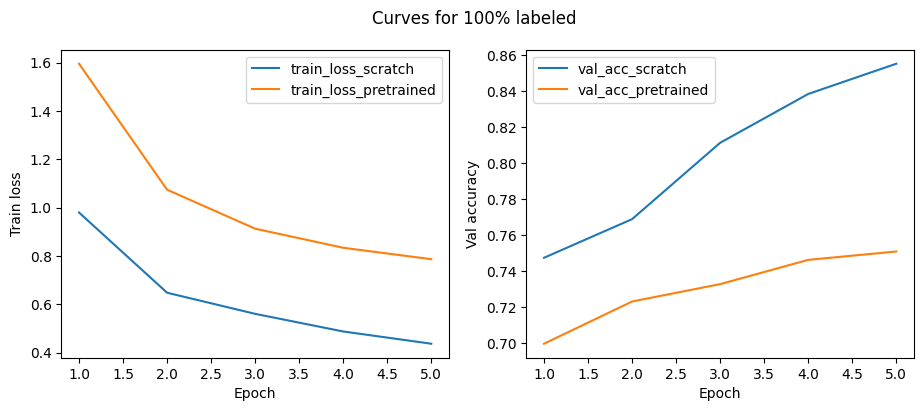

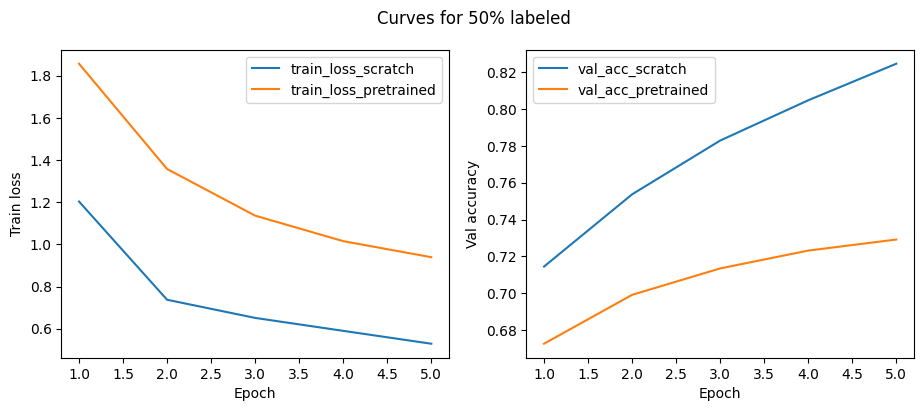

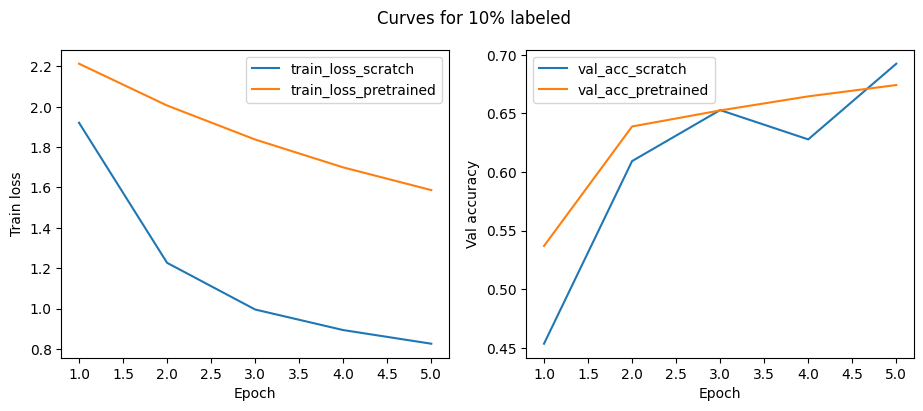

/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')
/tmp/ipython-input-3809632683.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  def to_pil(arr): return Image.fromarray(arr.astype('uint8'), mode='L')


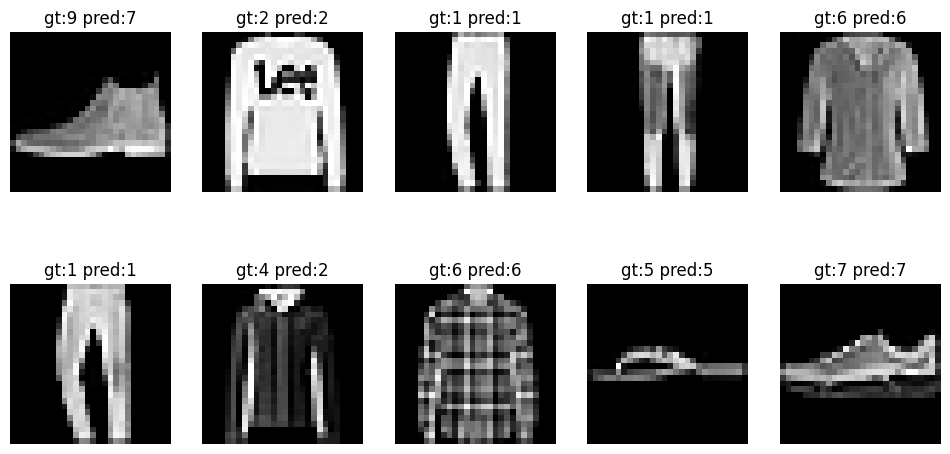

Final summary:
   percent  baseline_val_acc_max  baseline_test_acc  pretrained_val_acc_max  \
0      100              0.855333             0.8417                0.750833   
1       50              0.824500             0.8154                0.729167   
2       10              0.692333             0.6915                0.674167   

   pretrained_test_acc  
0               0.7401  
1               0.7223  
2               0.6676  


In [35]:
for perc in FRACTIONS:
    h_s, h_p, _, _ = plots_data[perc]
    epochs = list(range(1, CLF_EPOCHS+1))
    plt.figure(figsize=(11,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, h_s['train_loss'], label='train_loss_scratch')
    plt.plot(epochs, h_p['train_loss'], label='train_loss_pretrained')
    plt.xlabel("Epoch"); plt.ylabel("Train loss"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, h_s['val_acc'], label='val_acc_scratch')
    plt.plot(epochs, h_p['val_acc'], label='val_acc_pretrained')
    plt.xlabel("Epoch"); plt.ylabel("Val accuracy"); plt.legend()
    plt.suptitle(f"Curves for {perc}% labeled")
    plt.show()

if 100 in plots_data:
    model100 = plots_data[100][3]
else:
    model100 = plots_data[FRACTIONS[0]][3]
model100.to(device); model100.eval()
xb,yb = next(iter(test_loader))
with torch.no_grad():
    logits,_ = model100(xb[:10].to(device))
preds = logits.argmax(dim=1).cpu().numpy()
imgs = xb[:10].numpy(); labs = yb[:10].numpy()
plt.figure(figsize=(12,6))
for i in range(10):
    ax = plt.subplot(2,5,i+1)
    im = imgs[i].squeeze()*0.5 + 0.5
    plt.imshow(im, cmap='gray'); plt.axis('off')
    ax.set_title(f"gt:{labs[i]} pred:{preds[i]}")
plt.show()

print("Final summary:")
print(df[['percent','baseline_val_acc_max','baseline_test_acc','pretrained_val_acc_max','pretrained_test_acc']])

В работе использовался датасет FashionMNIST — 10 классов изображений одежды размером 28×28 пикселей в градациях серого.
Для экспериментов брались подвыборки размеченных данных объёмом 100%, 50% и 10% от исходного обучающего набора.

Были проведены два типа экспериментов:

Baseline (без предобучения) — модель обучалась с нуля на размеченной части данных.

Self-supervised (c предобученным feature extractor) — энкодер предварительно обучался на всём наборе изображений без меток с использованием self-supervised подхода (предтекстовая задача), после чего использовался как фиксированный feature extractor при обучении классификатора на размеченных примерах.

Оценка проводилась по стандартным метрикам:

Accuracy (доля правильно классифицированных изображений) — основная метрика.

Отслеживались также кривые лоссов (train/val loss) и динамика accuracy по эпохам.

Изменение лосса

У Baseline модели лосс на обучении снижался быстрее и достигал стабильных значений за 3–4 эпохи.

У предобученного feature extractor кривая убывала медленнее, особенно при 10% и 50% данных — это связано с тем, что энкодер был заморожен (freeze) и не дообучался под конкретную задачу классификации.

При 100% данных видно, что лосс Baseline достигает минимума быстрее и на более низком уровне.

Вывод: Baseline-сеть обучалась быстрее по лоссу, так как имела больше степени свободы в весах; pretrained-сеть стабилизировалась медленнее, но показывала меньшую переобучаемость.

В данном эксперименте Baseline outperform’ит Pretrained модель,
так как энкодер был заморожен (не fine-tuned) и не адаптировался к задаче классификации.
Если бы использовался fine-tuning encoder, результаты self-supervised подхода, вероятно, были бы выше при малом количестве данных.